In [1]:
# 数值计算、表格、绘图、Gurobi，以及 Notebook 输出工具。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
from IPython.display import display, clear_output
from time import sleep
import planning_domain_demo as demo  # 笔记本与此文件放在同一目录。

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda value: f"{value:.9g}")
plt.rcParams.update({"font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"], "axes.unicode_minus": False})

In [2]:
TARGET_LAMBDA = 1.30  # 调参入口：修改后，重新运行本代码块，从第一轮开始。
config = demo.DemoConfig()
if not np.isfinite(TARGET_LAMBDA) or not 0 <= TARGET_LAMBDA <= config.lambda_search_max:
    raise ValueError(f"倍率必须在 [0, {config.lambda_search_max}] 内；更大范围请调整 config。")

# 重新初始化时，释放上一轮实验的求解器对象。
if "master" in globals(): master.dispose()
if "model" in globals(): model.subproblem.dispose()
model = demo.build_model(config)
cuts, history, details = [], [], {}  # cuts：已加入的割；history：摘要；details：每轮完整数值。
master, choices, alpha = demo.build_master(model, "min_cost", TARGET_LAMBDA, cuts)
sp, rows = model.subproblem, model.electrical_constraints
W, h, T, d, r = model.W, model.h, model.T, model.d, model.scales
FEAS_TOL, CHECK_TOL = config.feasibility_tolerance, 1e-7
LB, UB, finished, message = 0.0, np.inf, False, ""

# 向量顺序必须与 W、T 的列顺序一致：建设变量先走廊、再线型；w 先潮流、再平方电压。
ne, nk = len(model.corridors), len(model.lines)
x_vars = list(choices.values())
x_names = [f"x[{edge.name},{line.name}]" for edge in model.corridors for line in model.lines]
w_vars = [sp.getVarByName(f"P[{e}]") for e in range(ne)] + [sp.getVarByName(f"v[{i}]") for i in range(1, 4)]
w_names = [f"P{edge.name}" for edge in model.corridors] + ["v1", "v2", "v3"]
row_names = sp.getAttr("ConstrName", rows)

def cut_text(cut):
    """只对显示值进行舍入；实际添加约束时保留所有系数的完整精度。"""
    terms = [f"{cut.constant:.9g}"]
    terms += [f"{a:+.9g}*{name}" for a, name in zip(cut.x_coeff, x_names) if abs(a) > 1e-12]
    if abs(cut.lambda_coeff) > 1e-12: terms.append(f"{cut.lambda_coeff:+.9g}*lambda")
    return " ".join(terms) + " >= 0"

def step_mp1():
    """只推进一轮：MP1 → SP → 读取 pi → 加一条割或结束；不会自动求下一轮 MP1。"""
    global LB, UB, finished, message
    if finished: return None
    k, before = len(history) + 1, len(cuts)

    # ① 求 MP1：固定倍率，最小化建设费；包含结构约束和此前所有割。
    master.optimize()
    if master.Status == GRB.INFEASIBLE:
        finished, message = True, f"第 {k} 轮 MP1 不可行：当前倍率下没有满足模型的建设方案。"
        return None
    if master.Status != GRB.OPTIMAL:
        raise RuntimeError(f"MP1 尚未证明最优，状态码：{master.Status}")
    x = np.rint([v.X for v in x_vars]).astype(int)
    lam, cost = float(alpha.X), float(model.cost @ x)
    LB = max(LB, master.ObjBound * 1000)  # 源码的主问题目标单位是千元，此处换回元。

    # ② 固定建设方案和倍率，更新 SP：min eta，约束 Ww - r*eta <= b。
    b = h + T @ x + d * lam
    sp.setAttr("RHS", rows, b.tolist())
    sp.optimize()
    if sp.Status != GRB.OPTIMAL:
        raise RuntimeError(f"SP 未求得最优解，状态码：{sp.Status}")
    eta, w = float(sp.ObjVal), np.array([v.X for v in w_vars])

    # ③ 直接读取 LP 对偶乘子，不再单独求 Dual SP；本模型的理论 pi = -Gurobi.Pi。
    pi = -np.array(sp.getAttr("Pi", rows))
    cut = demo.DualCut(pi.copy(), float(pi @ h), pi @ T, float(pi @ d), eta)
    margin = float(cut.constant + cut.x_coeff @ x + cut.lambda_coeff * lam)
    stationarity, normalization = float(np.max(np.abs(W.T @ pi))), float(r @ pi)
    if min(pi) < -CHECK_TOL or stationarity > CHECK_TOL or normalization > 1 + CHECK_TOL or abs(margin + eta) > CHECK_TOL:
        raise RuntimeError("对偶校验未通过，暂不添加割，请检查数值精度。")

    # ④ 保存每条原约束的右端、残差、允许放松量和放松后的余量。
    lhs, relaxation = W @ w, r * eta
    row_table = pd.DataFrame({"h": h, "Tx": T @ x, "dλ": d * lam, "b": b, "Ww": lhs,
                             "原残差 Ww-b": lhs - b, "允许放松 rη": relaxation,
                             "放松后余量": b + relaxation - lhs, "pi": pi}, index=row_names)

    # ⑤ eta 超过容差才加割；满足原电气约束时，当前最优主问题方案即可接受。
    accepted = eta <= FEAS_TOL
    if accepted:
        UB, finished = cost, True
        message = f"已收敛：lambda={lam:g}，最小建设费={cost:,.0f} 元，共 {k} 轮、{before} 条割。"
    else:
        # 原始割：pi'h + (pi'T)x + (pi'd)lambda >= 0；正数缩放只用于改善数值条件。
        scale = max(1.0, abs(cut.constant), np.max(np.abs(cut.x_coeff)), abs(cut.lambda_coeff))
        expr = cut.constant + gp.LinExpr(cut.x_coeff.tolist(), x_vars) + cut.lambda_coeff * alpha
        master.addConstr(expr / scale >= 0, name=f"Benders_{before + 1}")
        master.update()
        cuts.append(cut)  # 下一次调用 step_mp1 时，MP1 就会包含这条新割。

    design = "; ".join(f"{edge.name}:{line.name}" for e, edge in enumerate(model.corridors)
                       for j, line in enumerate(model.lines) if x[e * nk + j])
    history.append({"轮次": k, "求解前割数": before, "求解后割数": len(cuts),
                    "候选费用/元": cost, "费用下界/元": LB, "费用上界/元": UB,
                    "SP违反量": eta, "动作": "接受并结束" if accepted else f"添加割 {len(cuts)}", "方案": design})
    details[k] = {"x": x.copy(), "lambda": lam, "w": w.copy(), "eta": eta, "pi": pi.copy(),
                  "b": b.copy(), "rows": row_table, "cut": None if accepted else cut,
                  "margin": margin, "stationarity": stationarity, "normalization": normalization}
    return details[k]

print(f"初始化完成：固定 lambda={TARGET_LAMBDA:g}；当前 0 条割。运行第三块定义画图函数，再运行第四块开始迭代。")

Set parameter WLSAccessID


Set parameter WLSSecret


Set parameter LicenseID to value 2685996


Academic license 2685996 - for non-commercial use only - registered to 20___@mail.scut.edu.cn


初始化完成：固定 lambda=1.3；当前 0 条割。运行第三块定义画图函数，再运行第四块开始迭代。


In [3]:
# 默认使用固定的预算 B—负荷倍率 lambda 坐标；前半部分保留旧的单条割三维图。
# 三维坐标：u = 本条割中 x 的加权贡献，lambda = 负荷倍率，K = 建设费用。
# 原始割：g_k(x, lambda) = beta_0 + beta_x @ x + beta_lambda * lambda >= 0。
# g_k 只是割左端的简称，不是费用目标，也不是到平面的欧氏距离。
# x 有 15 个分量；下面是保留“本条割满足/违反关系”的投影，不是完整可行域。
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import Markdown


def _cut_plot_data(k=None):
    """只读取已存记录，计算画图数据；不求解、不添加割、不推进迭代。"""
    if not details:
        return None
    requested_k = len(history) if k is None else k
    if requested_k not in details:
        raise ValueError(f"没有第 {requested_k} 轮记录。")
    # 收敛轮没有新割；自动回看最近一条，避免最终画面中割平面消失。
    available = [j for j in details if j <= requested_k and details[j]["cut"] is not None]
    if not available:
        return None
    k = max(available)
    rec, info = details[k], history[k - 1]
    cut, lam = rec["cut"], rec["lambda"]
    is_mp2 = "候选倍率" in info
    designs = demo.enumerate_designs(model)  # 全部 216 个结构合法方案，仅用于展示。
    X = np.vstack([item.x for item in designs])
    costs = np.array([item.cost_cny for item in designs])
    eligible = np.ones(len(X), dtype=bool)
    budget = None
    if is_mp2:
        # 读取初始化时实际加入的预算，避免之后只改 TARGET_COST 导致图与模型不符。
        budget = float(master.getConstrByName("budget").RHS * 1000)
        eligible &= costs <= budget + 1e-6
    old_cuts = cuts[:info["求解前割数"]]  # 回看历史时禁止混入后续割。
    before = eligible.copy()
    for old in old_cuts:
        before &= old.constant + X @ old.x_coeff + old.lambda_coeff * lam >= -FEAS_TOL
    g = cut.constant + X @ cut.x_coeff + cut.lambda_coeff * lam
    removed, after = before & (g < -FEAS_TOL), before & (g >= -FEAS_TOL)

    # 普通割用 u = beta_x @ x；纯倍率割用实际变量 x[01,L] 作展示轴，割中其系数仍为 0。
    has_x = bool(np.any(cut.x_coeff != 0))
    weights = cut.x_coeff if has_x else np.eye(1, model.nx, 0).ravel()
    u, current_u = X @ weights, float(weights @ rec["x"])
    u_label = r"建设贡献 $u=(\pi^\mathsf{T}T)x$" if has_x else f"建设变量 {x_names[0]}（此割不含 x）"

    def intervals(pool):
        # 对固定整数 x，每条线性割在 lambda 轴上给一个半区间；取交集即为 MP2 允许区间。
        lower, upper = np.zeros(len(X)), np.full(len(X), config.lambda_search_max)
        valid = eligible.copy()
        for item in pool:
            a, b = item.constant + X @ item.x_coeff, item.lambda_coeff
            if b < 0:
                upper = np.minimum(upper, -a / b)
            elif b > 0:
                lower = np.maximum(lower, -a / b)
            else:
                valid &= a >= -FEAS_TOL
        valid &= lower <= upper + 1e-10
        return lower, upper, valid

    old_interval = intervals(old_cuts) if is_mp2 else None
    new_interval = intervals([*old_cuts, cut]) if is_mp2 else None
    best = None
    if is_mp2:
        feasible = np.flatnonzero(new_interval[2])
        if len(feasible):
            best = int(feasible[np.argmax(new_interval[1][feasible])])
        next_value = float(new_interval[1][best]) if best is not None else -np.inf
        next_lam = next_value
    else:
        feasible = np.flatnonzero(after)
        if len(feasible):
            best = int(feasible[np.argmin(costs[feasible])])
        next_value = float(costs[best]) if best is not None else np.inf
        next_lam = lam
    return dict(k=k, requested_k=requested_k, rec=rec, info=info, cut=cut, lam=lam,
                is_mp2=is_mp2, budget=budget, X=X, costs=costs, eligible=eligible,
                before=before, removed=removed, after=after, g=g, u=u, current_u=current_u,
                u_label=u_label, has_x=has_x, old_interval=old_interval, new_interval=new_interval,
                best=best, next_value=next_value, next_lam=next_lam)


def plot_mp1_cut(k=None, *, elev=24, azim=-58):
    """兼容原调用，同时支持 MP1/MP2；画三维割平面和当前 lambda 截面。

    plot_mp1_cut(1) 回看第一轮；elev、azim 调整三维观察角度。
    此函数名称为兼容原 notebook 保留，MP2 会按预算与倍率目标正确绘图。
    """
    data = _cut_plot_data(k)
    if data is None:
        print("尚无可展示的割：请先运行 MP1/SP 或 MP2/SP；若首轮已可行，则无需加割。")
        return
    k, rec, info, cut = data["k"], data["rec"], data["info"], data["cut"]
    lam, is_mp2 = data["lam"], data["is_mp2"]
    u, costs = data["u"], data["costs"] / 1000  # 图中费用用千元，原模型与记录仍为元。
    before, removed, after = data["before"], data["removed"], data["after"]
    current_u, current_cost = data["current_u"], float(model.cost @ rec["x"] / 1000)
    b0, bl = cut.constant, cut.lambda_coeff
    cut_u = -b0 - bl * lam
    old_interval, new_interval = data["old_interval"], data["new_interval"]
    visible = old_interval[2] if is_mp2 else before
    extent_u = np.r_[u[visible], current_u, cut_u] if data["has_x"] else np.array([-0.1, 1.1])
    pad_u = max(0.08 * float(np.ptp(extent_u)), 0.02)
    u_min, u_max = float(extent_u.min() - pad_u), float(extent_u.max() + pad_u)
    extent_cost = np.r_[costs[visible], current_cost]
    pad_cost = max(0.08 * float(np.ptp(extent_cost)), 1.0)
    z_min, z_max = float(extent_cost.min() - pad_cost), float(extent_cost.max() + pad_cost)
    lambda_max = config.lambda_search_max
    red, green, blue, gold = "#DC2626", "#087F6D", "#2563EB", "#F59E0B"
    fig = plt.figure(figsize=(14.8, 7.4))
    grid = fig.add_gridspec(1, 2, width_ratios=[1.35, 1], left=0.02, right=0.97,
                           bottom=0.24, top=0.81, wspace=0.14)
    ax = fig.add_subplot(grid[0], projection="3d", computed_zorder=False)
    section = fig.add_subplot(grid[1])

    # 直接画 g=0 平面，费用轴的系数为 0：割并不含目标函数 K。
    if data["has_x"]:
        lambda_edges = np.array([0.0, lambda_max])
        if bl != 0:
            crossing = np.sort((-b0 - np.array([u_min, u_max])) / bl)
            lambda_edges = np.array([max(0.0, crossing[0]), min(lambda_max, crossing[1])])
        plane_lambda, plane_cost = np.meshgrid(lambda_edges, [z_min, z_max])
        plane_u = -b0 - bl * plane_lambda
        ax.plot_surface(plane_u, plane_lambda, plane_cost, color=blue, alpha=0.22,
                        edgecolor=blue, linewidth=0.8, shade=False, zorder=1)
        # 深蓝竖线是该平面与“本轮固定 lambda”截面的交线。
        ax.plot([cut_u, cut_u], [lam, lam], [z_min, z_max], color=blue, linewidth=2.5, zorder=3)
        section.axvline(cut_u, color=blue, linewidth=2)
        section.axvspan(u_min, cut_u, color=red, alpha=0.07)
        section.axvspan(cut_u, u_max, color=green, alpha=0.07)
        section_note = f"排除 u < {cut_u:.6g}；保留 u ≥ {cut_u:.6g}"
        equation = f"u {bl:+.6g} λ {b0:+.6g} = 0"
    elif bl != 0:
        # 如 MP2 首轮的 lambda <= 2.375：直接画常倍率平面，不虚构 x 的系数。
        plane_u, plane_cost = np.meshgrid([u_min, u_max], [z_min, z_max])
        ax.plot_surface(plane_u, np.full_like(plane_u, -b0 / bl), plane_cost,
                        color=blue, alpha=0.22, edgecolor=blue, linewidth=0.8, shade=False, zorder=1)
        section.set_facecolor("#FEF2F2" if b0 + bl * lam < -FEAS_TOL else "#F0FDFA")
        sense = "≤" if bl < 0 else "≥"
        section_note = f"此割只要求 λ {sense} {-b0 / bl:.6g}，与建设费用无关"
        equation = f"λ = {-b0 / bl:.6g}（与 x、费用无关）"
    else:
        equation = f"常数割 {b0:.6g} ≥ 0（无非退化边界平面）"
        section_note = "常数割对整个截面作相同判断"

    if is_mp2:
        old_lo, old_hi, old_valid = old_interval
        new_lo, new_hi, new_valid = new_interval
        # 红线先画旧区间，绿线覆盖新保留区间；露出的红段才是本条割新排除的部分。
        for i in np.flatnonzero(old_valid):
            ax.plot([u[i], u[i]], [old_lo[i], old_hi[i]], [costs[i], costs[i]],
                    color=red, alpha=0.45, linewidth=1.2, zorder=2)
        for i in np.flatnonzero(new_valid):
            ax.plot([u[i], u[i]], [new_lo[i], new_hi[i]], [costs[i], costs[i]],
                    color=green, alpha=0.65, linewidth=1.4, zorder=3)
        ax.scatter(u[new_valid], new_hi[new_valid], costs[new_valid], s=20,
                   color=green, depthshade=False, zorder=4)
        mode_title = f"MP2：预算 {data['budget']:,.0f} 元，最大化 λ"
        left_title = "三维割平面：红段被切掉，绿段仍被当前 MP2 允许"
        old_value = float(old_hi[old_valid].max()) if old_valid.any() else -np.inf
        effect = (f"MP2 倍率上界：{old_value:.9g} → {data['next_value']:.9g}"
                  if data["best"] is not None else "加割后当前预算下无候选区间，下一轮 MP2 将不可行")
    else:
        ax.scatter(u[removed], np.full(removed.sum(), lam), costs[removed], marker="x",
                   color=red, s=34, depthshade=False, zorder=4)
        ax.scatter(u[after], np.full(after.sum(), lam), costs[after], color=green,
                   s=25, alpha=0.75, depthshade=False, zorder=4)
        mode_title = f"MP1：固定 λ = {lam:g}，最小化建设费用"
        left_title = "三维割平面：所有候选都在本轮固定 λ 的截面内"
        effect = (f"MP1 费用下界：{current_cost * 1000:,.0f} → {data['next_value']:,.0f} 元"
                  if data["best"] is not None else "加割后没有剩余候选，下一轮 MP1 将不可行")

    # 当前候选在割的违反侧；黑星不表示已通过 SP 检验。
    ax.scatter([current_u], [lam], [current_cost], marker="*", s=230, color="#111827",
               edgecolor="white", linewidth=0.7, depthshade=False, zorder=7)
    section.scatter(u[removed], costs[removed], s=34, marker="x", color=red)
    section.scatter(u[after], costs[after], s=27, color=green, alpha=0.75)
    section.scatter(current_u, current_cost, marker="*", s=230, color="#111827",
                    edgecolor="white", linewidth=0.7, zorder=6)
    best = data["best"]
    if best is not None:
        ax.scatter([u[best]], [data["next_lam"]], [costs[best]], marker="*", s=250,
                   color=gold, edgecolor="#111827", linewidth=0.7, depthshade=False, zorder=8)
        if not is_mp2:
            section.scatter(u[best], costs[best], marker="*", s=250, color=gold,
                            edgecolor="#111827", linewidth=0.7, zorder=7)

    ax.set(xlim=(u_min, u_max), ylim=(0, lambda_max), zlim=(z_min, z_max))
    ax.set_xlabel(data["u_label"], labelpad=12, fontsize=10)
    ax.set_ylabel("负荷倍率 λ", labelpad=10, fontsize=11)
    ax.set_zlabel("建设费用 K(x) / 千元", labelpad=10, fontsize=10)
    ax.set_title(left_title, fontsize=11, pad=18)
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1.15, 1, 0.85))
    section.set(xlim=(u_min, u_max), ylim=(z_min, z_max), xlabel=data["u_label"],
                ylabel="建设费用 K(x) / 千元")
    section.set_title(f"固定 λ = {lam:.6g} 的截面\n{before.sum()} 个候选 → 排除 {removed.sum()} 个 → 剩余 {after.sum()} 个\n{section_note}",
                      fontsize=10, pad=14)
    section.grid(alpha=0.18)
    replay = f"（第 {data['requested_k']} 轮无新割，回看此割）" if k != data["requested_k"] else ""
    fig.suptitle(f"第 {k} 轮 · 第 {info['求解前割数'] + 1} 条可行性割 {replay}\n{mode_title}\n蓝色平面：{equation}",
                 fontsize=13, y=0.98, linespacing=1.5)
    handles = [Patch(facecolor=blue, alpha=0.25, edgecolor=blue, label="新割边界平面 g = 0"),
               Line2D([], [], color=red, marker="x", linestyle="-" if is_mp2 else "None", label="本条割新排除"),
               Line2D([], [], color=green, marker="o", linestyle="-" if is_mp2 else "None", label="加割后仍允许（尚需 SP 检验）"),
               Line2D([], [], color="#111827", marker="*", markersize=12, linestyle="None", label="产生本条割的候选"),
               Line2D([], [], color=gold, marker="*", markeredgecolor="#111827", markersize=12,
                      linestyle="None", label="加割后最优候选之一（枚举核对）")]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.06), ncol=3, fontsize=10, frameon=False)
    fig.text(0.5, 0.022, effect + "；平面按线性式延展，图中连续空白位置不一定对应合法整数建设方案。",
             ha="center", fontsize=10)
    plt.show()
    plt.close(fig)
    print(f"本条割：{cut_text(cut)}")
    print(f"g_k 是上式左端；当前候选 g_k = {rec['margin']:.9g} = -eta，故被排除。")
    print(effect + "。金色星号是按已加割枚举得到的候选，不会自动执行下一轮求解。")
    if is_mp2:
        print("右图只检查当前 λ 这一层；红点所代表的建设方案，降低 λ 后仍可能保留在左图绿段中。")
    print("不同割使用不同的建设贡献 u；该投影保留本条割的正负判断，但不能还原完整的 15 维建设选择。")



def _domain_states(problem, pool):
    """把累计割投影到固定的预算 B—倍率 lambda 坐标；枚举仅用于画图和独立核对。"""
    designs = demo.enumerate_designs(problem)
    X = np.vstack([item.x for item in designs])
    costs = np.array([item.cost_cny for item in designs])
    exact_caps = np.minimum([item.lambda_max for item in designs], problem.config.lambda_search_max)
    # 所有整数方案的费用都是潜在跳点，保留全部跳点，不用均匀采样近似阶梯。
    budget_max = max(1000.0, float(np.ceil(costs.max() / 1000) * 1000))
    budgets = np.unique(np.r_[0.0, costs, budget_max])
    order = np.argsort(costs)
    ends = np.searchsorted(costs[order], budgets, side="right") - 1
    has_design = ends >= 0

    def envelope(capacities):
        best = np.maximum.accumulate(capacities[order])
        result = np.full(len(budgets), np.nan)
        result[has_design] = best[ends[has_design]]
        result[~np.isfinite(result)] = np.nan
        return result

    lo = np.zeros(len(X))
    hi = np.full(len(X), problem.config.lambda_search_max)
    valid = np.ones(len(X), dtype=bool)
    frames = [envelope(hi)]
    for cut in pool:
        a, b = cut.constant + X @ cut.x_coeff, cut.lambda_coeff
        if b < 0:
            hi = np.minimum(hi, -a / b)
        elif b > 0:
            lo = np.maximum(lo, -a / b)
        else:
            valid &= a >= -1e-8
        allowed = valid & (lo <= hi + 1e-9)
        # 本算例每个建设方案在零负荷下可行，故倍率区间从 0 开始。
        # 若模型以后改变为存在正下界/空洞，就不能继续用“曲线下方全填色”的画法。
        if np.any(lo[allowed] > 1e-8):
            raise ValueError("当前模型存在非零倍率下界，需改画区间并集，不能填满曲线下方。")
        caps = np.where(allowed, np.maximum(hi, 0.0), -np.inf)
        frames.append(envelope(caps))
    return {"budgets": budgets, "frames": np.array(frames), "exact": envelope(exact_caps),
            "budget_max": budget_max, "lambda_max": problem.config.lambda_search_max,
            "designs": designs}


def _draw_domain_state(data, count, previous=None, *, title="累计割的预算—负荷投影", query=None, show_exact=False):
    """各帧使用完全相同的横纵坐标和坐标范围；返回图对象以便导出或显示。"""
    previous = max(0, count - 1) if previous is None else previous
    B = data["budgets"] / 1000
    before, after = data["frames"][previous], data["frames"][count]
    fig, ax = plt.subplots(figsize=(10.5, 6.0))
    fig.subplots_adjust(left=0.09, right=0.97, bottom=0.22, top=0.86)
    ax.fill_between(B, 0, after, step="post", color="#0F766E", alpha=0.16,
                    label="目前尚未排除的区域（外近似）")
    ax.fill_between(B, after, before, step="post", color="#DC2626", alpha=0.35,
                    label="本次新增割排除的区域")
    ax.step(B, before, where="post", color="#64748B", linestyle="--", linewidth=1.5,
            label=f"此前边界：{previous} 条割")
    ax.step(B, after, where="post", color="#0F766E", linewidth=2.2,
            label=f"当前边界：{count} 条割")
    if show_exact:
        ax.step(B, data["exact"], where="post", color="#111827", linestyle=":", linewidth=1.7,
                label="精确电气边界（独立枚举校验）")
    if query is not None:
        mode, value = query
        if mode == "min_cost":
            ax.axhline(value, color="#D97706", linestyle=":", linewidth=1.2, label=f"MP1 固定倍率 {value:g}")
            candidates = np.flatnonzero(after >= value - 1e-8)
            if len(candidates):
                ax.scatter(B[candidates[0]], value, marker="*", s=160, color="#D97706", zorder=5)
        else:
            ax.axvline(value / 1000, color="#D97706", linestyle=":", linewidth=1.2,
                       label=f"MP2 固定预算 {value:,.0f} 元")
            index = np.searchsorted(data["budgets"], value, side="right") - 1
            if index >= 0 and np.isfinite(after[index]):
                ax.scatter(value / 1000, after[index], marker="*", s=160, color="#D97706", zorder=5)
    ax.set(xlim=(0, data["budget_max"] / 1000), ylim=(0, data["lambda_max"] * 1.04),
           xlabel="建设预算 B / 千元（允许花费的上限）", ylabel="负荷倍率 λ（无量纲）")
    ax.set_title(f"{title}\n累计 {previous} → {count} 条割；横纵坐标及刻度始终不变", fontsize=13, pad=12)
    ax.grid(alpha=0.18)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2, fontsize=9, frameon=False)
    return fig


def plot_domain_cuts(k=None, *, show_exact=False):
    """画本次 MP1/MP2 实验第 k 轮的区域收缩；k=0 看初始区域，不额外求解。"""
    k = len(history) if k is None else k
    if k == 0:
        before = after = 0
        query = None
    else:
        if k not in details:
            raise ValueError(f"没有第 {k} 轮记录。")
        info, rec = history[k - 1], details[k]
        before, after = info["求解前割数"], info["求解后割数"]
        query = (("max_lambda", float(master.getConstrByName("budget").RHS * 1000))
                 if "候选倍率" in info else ("min_cost", rec["lambda"]))
    data = _domain_states(model, cuts[:after])  # 历史帧不使用后续割。
    fig = _draw_domain_state(data, after, before, title=f"第 {k} 轮：固定预算—负荷坐标下的区域收缩",
                             query=query, show_exact=show_exact)
    plt.show()
    plt.close(fig)
    if after > before and np.allclose(data["frames"][before], data["frames"][after], atol=1e-8, rtol=0, equal_nan=True):
        print("这一条割收紧了部分建设方案，但其他方案仍支撑相同的预算—负荷边界，所以外轮廓暂未移动。")
    print("每个 (B, λ) 点表示：是否还存在至少一个费用不超过 B、且通过当前所有割的建设方案。")
    print("单次 MP1/MP2 收敛仅证明当前查询完成；恢复完整区域可运行 play_domain_cuts(full=True)。")


def play_domain_cuts(*, full=False, pause=0.6, show_exact=False):
    """固定坐标逐条回放；full=True 用独立模型恢复完整边界，不改当前 MP1/MP2 实验。"""
    if not np.isfinite(pause) or pause < 0:
        raise ValueError("pause 必须是非负有限秒数。")
    if full:
        problem, pool = demo.build_model(config), []
        try:
            frontier = demo.discover_frontier_by_cuts(problem, pool)
            data = _domain_states(problem, pool)
        finally:
            problem.subproblem.dispose()
        if not np.allclose(data["frames"][-1], data["exact"], atol=1e-7, rtol=0, equal_nan=True):
            raise RuntimeError("累计割投影尚未与独立电气边界一致，不能宣称完整域恢复。")
        title = "完整规划域：跨预算 MP2/MP1 搜索产生的真实割"
    else:
        data = _domain_states(model, cuts)
        title = "本次 MP 查询已有割的回放（不保证覆盖整个边界）"
    for count in range(len(data["frames"])):
        clear_output(wait=True)
        fig = _draw_domain_state(data, count, title=title, show_exact=show_exact)
        plt.show()
        plt.close(fig)
        if count + 1 < len(data["frames"]):
            sleep(pause)
    if full:
        print(f"完整域回放结束：{len(data['frames']) - 1} 条割，{len(frontier)} 个前沿台阶，已通过独立校验。")
    else:
        print("已有割回放结束；绿色仍表示外近似。完整域请使用 full=True。")


display(Markdown(r"""
**默认读图：横轴为建设预算 $B$，纵轴为负荷倍率 $\lambda$，各轮坐标和刻度固定。**
绿色区域表示当前尚未排除的预算—负荷组合，红色带是本条新割刚排除的部分。
因为存在整数建设选择，边界是阶梯；图中画的是累计割投影后的区域，并非把每条高维割直接画成直线。

- 第 4、6 块默认调用 `plot_domain_cuts(k)`，随 MP1/MP2 每轮自动更新。
- `plot_domain_cuts(0)` 看初始域；`plot_domain_cuts(1)` 回看第一轮。
- `play_domain_cuts()` 回放当前已有割；`play_domain_cuts(full=True)` 在独立模型上恢复并回放完整域。
- 原来的单条割三维图仍可用 `plot_mp1_cut(1)` 查看，但它的建设贡献轴会随割改变。

一个预算—负荷点可以对应多个建设方案。某个方案被切掉时，另一个方案可能仍然支撑这个点，
因此并非每一条割都会改变这里的外轮廓。单次 MP1/MP2 收敛也不等于整个域已恢复。
"""))



**默认读图：横轴为建设预算 $B$，纵轴为负荷倍率 $\lambda$，各轮坐标和刻度固定。**
绿色区域表示当前尚未排除的预算—负荷组合，红色带是本条新割刚排除的部分。
因为存在整数建设选择，边界是阶梯；图中画的是累计割投影后的区域，并非把每条高维割直接画成直线。

- 第 4、6 块默认调用 `plot_domain_cuts(k)`，随 MP1/MP2 每轮自动更新。
- `plot_domain_cuts(0)` 看初始域；`plot_domain_cuts(1)` 回看第一轮。
- `play_domain_cuts()` 回放当前已有割；`play_domain_cuts(full=True)` 在独立模型上恢复并回放完整域。
- 原来的单条割三维图仍可用 `plot_mp1_cut(1)` 查看，但它的建设贡献轴会随割改变。

一个预算—负荷点可以对应多个建设方案。某个方案被切掉时，另一个方案可能仍然支撑这个点，
因此并非每一条割都会改变这里的外轮廓。单次 MP1/MP2 收敛也不等于整个域已恢复。


第 10 轮：MP1 → SP → 添加新割
固定倍率=1.3；候选费用=31,360 元；eta=0.0208180980198

建设选择：


,建设变量,上一轮,本轮
0,"x[01,M]",0,1
1,"x[01,H]",1,0
2,"x[13,L]",1,1
3,"x[02,L]",0,1
4,"x[23,M]",1,0



SP 运行变量（P：kW；v：平方电压；eta>容差时为放松后的试算值）：


,变量,本轮,较上一轮变化
0,P01,47.0036565,-13.6831104
1,P12,-1.24908588,-5.57739417
2,P13,17.0018282,-11.1849386
3,P02,29.7472576,25.4189494
4,P23,1.24908588,14.264161
5,v1,0.919272433,-0.0326808294
6,v2,0.865969191,0.0108150986
7,v3,0.862087475,-0.000143858911



对偶乘子及对应约束：


,b,Ww,原残差 Ww-b,允许放松 rη,放松后余量,pi
capacity_12_-1,0,1.24908588,1.24908588,1.24908588,0,0.00141582196
capacity_23_1,0,1.24908588,1.24908588,1.24908588,0,0.00422696369
balance_1_-1,-32.5,-31.2509141,1.24908588,1.24908588,0,0.00141582196
balance_3_-1,-19.5,-18.2509141,1.24908588,1.24908588,0,0.00422696369
voltage_lower_3,-0.8649,-0.862087475,0.00281252504,0.00281252504,0,0.796609234
drop_upper_01_M,1,1.00281253,0.00281252504,0.00281252504,0,0.796609234
drop_upper_13_L,0,0.00281252504,0.00281252504,0.00281252504,5.37764278e-17,0.796609234


对偶检查：max|W.T@pi|=0.000e+00；r@pi=1

新割 10（显示值经舍入）：
0.745562091 -0.249204103*x[01,M] +0.0495537686*x[12,L] +0.0920284273*x[12,M] +0.141582196*x[12,H] -0.38873608*x[13,L] +0.147943729*x[23,L] +0.27475264*x[23,M] +0.422696369*x[23,H] -0.0988000043*lambda >= 0
当前候选代入割的左端=-0.0208180980198；应等于 -eta=-0.0208180980198
新割已经加入；下次运行本块，MP1 将在这些割的约束下重新选方案。


,割编号,当前候选代入左端,本轮新增
0,1,0.0733333333,False
1,2,0.592704834,False
2,3,0.241807879,False
3,4,0.673781007,False
4,5,0.709125752,False
5,6,0.332929475,False
6,7,0.222199913,False
7,8,0.688456259,False
8,9,0.304790135,False
9,10,-0.020818098,True



累计迭代记录（上界为 inf 表示尚未找到通过 SP 检验的方案）：


,轮次,求解前割数,求解后割数,候选费用/元,费用下界/元,费用上界/元,SP违反量,动作,方案
0,1,0,1,0,0,inf,0.143333333,添加割 1,01:L; 12:L; 13:L
1,2,1,2,14300,14300,inf,0.00882199892,添加割 2,01:H; 12:L; 13:L
2,3,2,3,22040,22040,inf,0.00756011061,添加割 3,01:H; 12:M; 13:L
3,4,3,4,24620,24620,inf,0.00719966934,添加割 4,01:H; 12:L; 13:M
4,5,4,5,25980,25980,inf,0.0625443893,添加割 5,01:H; 12:L; 23:L
5,6,5,6,25980,25980,inf,0.0789033528,添加割 6,01:H; 13:L; 23:L
6,7,6,7,26400,26400,inf,0.0634988962,添加割 7,01:L; 13:L; 02:M
7,8,7,8,28380,28380,inf,0.0543903176,添加割 8,01:H; 12:L; 23:M
8,9,8,9,28380,28380,inf,0.0721384715,添加割 9,01:H; 13:L; 23:M
9,10,9,10,31360,31360,inf,0.020818098,添加割 10,01:M; 13:L; 02:L


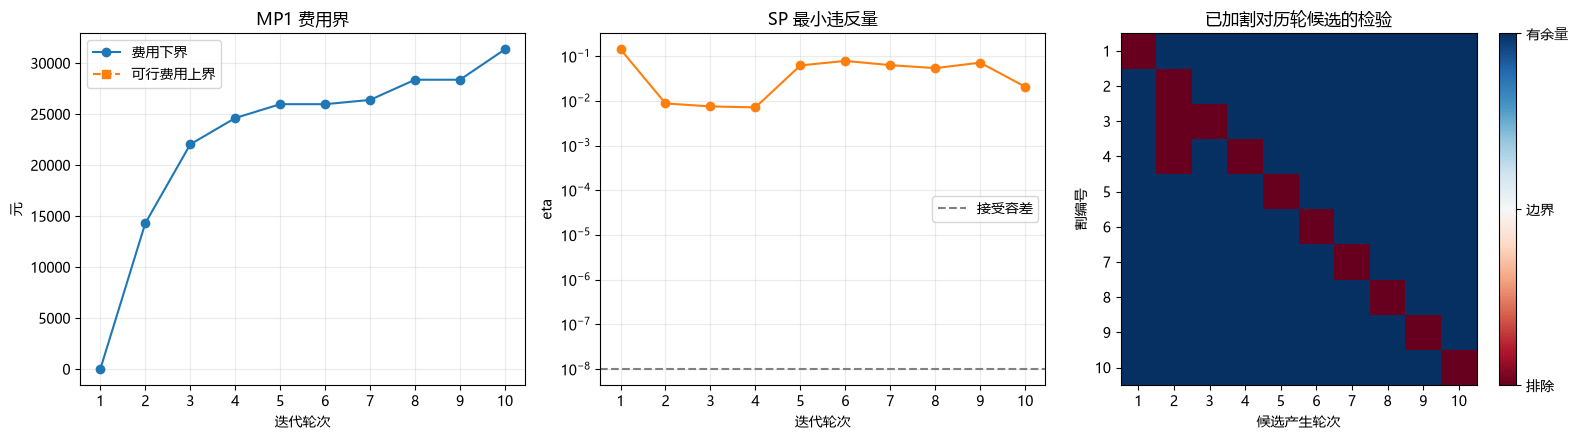

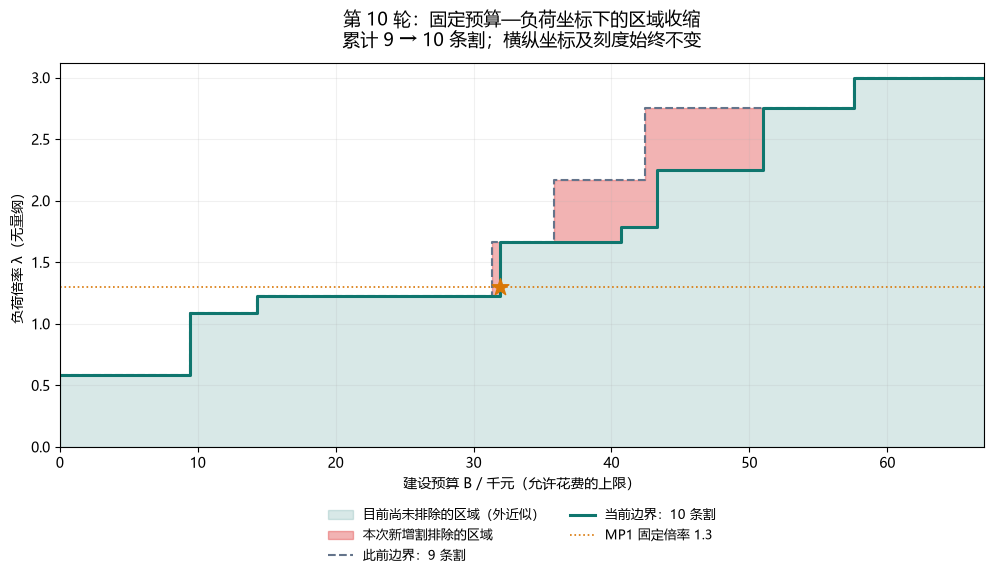

每个 (B, λ) 点表示：是否还存在至少一个费用不超过 B、且通过当前所有割的建设方案。
单次 MP1/MP2 收敛仅证明当前查询完成；恢复完整区域可运行 play_domain_cuts(full=True)。


In [4]:
STEPS = 10              # 1：每次运行只推进一轮；改成 20：逐轮自动播放，收敛后自动停止。
PAUSE = 1            # 自动播放时，两轮之间暂停的秒数。
SHOW_ALL_ROWS = False  # False：只显示非零 pi 对应的行；True：显示全部电气约束。

for step in range(STEPS):
    if finished:
        print(message + " 修改倍率并重跑第二块，可开始新实验。")
        break
    result = step_mp1()
    clear_output(wait=True)  # 刷新画面；历史数据始终保存在 history、details、cuts 中。
    if result is None:
        print(message)
        display(pd.DataFrame(history))
        break

    k, previous = len(history), details.get(len(history) - 1)
    print(f"第 {k} 轮：MP1 → SP → {'接受方案' if finished else '添加新割'}")
    print(f"固定倍率={result['lambda']:g}；候选费用={history[-1]['候选费用/元']:,.0f} 元；eta={result['eta']:.12g}")

    # A. 展示建设变量变化：保留本轮选中的项，以及较上一轮变化的项。
    x_before = previous["x"] if previous else np.full(model.nx, np.nan)
    x_table = pd.DataFrame({"建设变量": x_names, "上一轮": x_before, "本轮": result["x"]})
    mask = result["x"] != 0
    if previous: mask |= result["x"] != x_before
    print("\n建设选择：")
    display(x_table.loc[mask].reset_index(drop=True))

    # B. 展示 SP 求出的运行变量；eta>容差时，这些是放松后的试算值。
    w_before = previous["w"] if previous else np.full(len(w_names), np.nan)
    print("\nSP 运行变量（P：kW；v：平方电压；eta>容差时为放松后的试算值）：")
    display(pd.DataFrame({"变量": w_names, "本轮": result["w"], "较上一轮变化": result["w"] - w_before}))
    selected = result["rows"] if SHOW_ALL_ROWS else result["rows"].loc[np.abs(result["pi"]) > 1e-10]
    print("\n对偶乘子及对应约束：")
    display(selected[["b", "Ww", "原残差 Ww-b", "允许放松 rη", "放松后余量", "pi"]])
    print(f"对偶检查：max|W.T@pi|={result['stationarity']:.3e}；r@pi={result['normalization']:.12g}")

    # C. 显示刚加入的割，以及当前候选对所有已加割的满足情况。
    if result["cut"] is not None:
        print(f"\n新割 {len(cuts)}（显示值经舍入）：\n{cut_text(result['cut'])}")
        print(f"当前候选代入割的左端={result['margin']:.12g}；应等于 -eta={-result['eta']:.12g}")
        print("新割已经加入；下次运行本块，MP1 将在这些割的约束下重新选方案。")
    if cuts:
        display(pd.DataFrame({"割编号": range(1, len(cuts) + 1),
                              "当前候选代入左端": [c.constant + c.x_coeff @ result["x"] + c.lambda_coeff * result["lambda"] for c in cuts],
                              "本轮新增": [result["cut"] is c for c in cuts]}))

    # D. 历史表和图始终累计全部已完成的迭代，不会因刷新画面而丢失。
    trace = pd.DataFrame(history)
    print("\n累计迭代记录（上界为 inf 表示尚未找到通过 SP 检验的方案）：")
    display(trace)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
    ax[0].plot(trace["轮次"], trace["费用下界/元"], "o-", label="费用下界")
    ax[0].plot(trace["轮次"], trace["费用上界/元"].replace(np.inf, np.nan), "s--", label="可行费用上界")
    ax[0].set(title="MP1 费用界", xlabel="迭代轮次", ylabel="元"); ax[0].legend()
    ax[1].plot(trace["轮次"], trace["SP违反量"], "o-", color="tab:orange")
    ax[1].axhline(FEAS_TOL, color="gray", linestyle="--", label="接受容差")
    ax[1].set_yscale("symlog", linthresh=FEAS_TOL)  # 保留 eta=0，同时看清较小的违反量。
    ax[1].set(title="SP 最小违反量", xlabel="迭代轮次", ylabel="eta"); ax[1].legend()
    for axis in ax[:2]: axis.set_xticks(trace["轮次"]); axis.grid(alpha=0.25)

    # 每条已加割回测每个历史候选：红色表示排除，白色表示在边界，蓝色表示有余量。
    if cuts:
        margins = np.array([[c.constant + c.x_coeff @ rec["x"] + c.lambda_coeff * rec["lambda"]
                             for rec in details.values()] for c in cuts])
        signs = np.where(margins < -FEAS_TOL, -1, np.where(margins > FEAS_TOL, 1, 0))
        im = ax[2].imshow(signs, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
        ax[2].set_xticks(np.arange(k), np.arange(1, k + 1))
        ax[2].set_yticks(np.arange(len(cuts)), np.arange(1, len(cuts) + 1))
        bar = fig.colorbar(im, ax=ax[2], ticks=[-1, 0, 1])
        bar.ax.set_yticklabels(["排除", "边界", "有余量"])
    else:
        ax[2].text(0.5, 0.5, "尚未添加割", ha="center", va="center", transform=ax[2].transAxes)
    ax[2].set(title="已加割对历轮候选的检验", xlabel="候选产生轮次", ylabel="割编号")
    plt.tight_layout(); plt.show(); plt.close(fig)
    plot_domain_cuts(k) 
    if finished:
        print(message)
        break
    if step + 1 < STEPS: sleep(PAUSE)

# 回看某轮完整数据，例如：details[2]["rows"]、details[2]["pi"]、details[2]["x"]。
# 查看全部割的式子，例如：[cut_text(c) for c in cuts]。

In [5]:
TARGET_COST = 32360  # 调参入口：修改后，重新运行本代码块，从第一轮开始。
config = demo.DemoConfig()

# 重新初始化时，释放上一轮实验的求解器对象。
if "master" in globals(): master.dispose()
if "model" in globals(): model.subproblem.dispose()
model = demo.build_model(config)
cuts, history, details = [], [], {}
master, choices, alpha = demo.build_master(model, "max_lambda", TARGET_COST, cuts)
sp, rows = model.subproblem, model.electrical_constraints
W, h, T, d, r = model.W, model.h, model.T, model.d, model.scales
FEAS_TOL, CHECK_TOL = config.feasibility_tolerance, 1e-7

# MP2 的 LB、UB 都是负荷倍率，不是费用。默认模型在非负预算下，lambda=0 可行。
LB, UB, finished, message = 0.0, config.lambda_search_max, False, ""
ne, nk = len(model.corridors), len(model.lines)
x_vars = list(choices.values())
x_names = [f"x[{edge.name},{line.name}]" for edge in model.corridors for line in model.lines]
w_vars = [sp.getVarByName(f"P[{e}]") for e in range(ne)] + [sp.getVarByName(f"v[{i}]") for i in range(1, 4)]
w_names = [f"P{edge.name}" for edge in model.corridors] + ["v1", "v2", "v3"]
row_names = sp.getAttr("ConstrName", rows)

def cut_text(cut):
    """只对显示值进行舍入；实际添加约束时保留所有系数的完整精度。"""
    terms = [f"{cut.constant:.9g}"]
    terms += [f"{a:+.9g}*{name}" for a, name in zip(cut.x_coeff, x_names) if abs(a) > 1e-12]
    if abs(cut.lambda_coeff) > 1e-12: terms.append(f"{cut.lambda_coeff:+.9g}*lambda")
    return " ".join(terms) + " >= 0"

def step_mp2():
    """只推进一轮：MP2 → SP → 读取 pi → 加一条割或结束；不会自动求下一轮 MP2。"""
    global LB, UB, finished, message
    if finished: return None
    k, before = len(history) + 1, len(cuts)

    # ① 求 MP2：固定建设成本预算，最大化倍率；包含结构约束和此前所有割。
    master.optimize()
    if master.Status == GRB.INFEASIBLE:
        finished, message = True, f"第 {k} 轮 MP2 不可行：当前预算下没有满足模型的方案。"
        return None
    if master.Status != GRB.OPTIMAL:
        raise RuntimeError(f"MP2 尚未证明最优，状态码：{master.Status}")
    x = np.rint([v.X for v in x_vars]).astype(int)
    lam, cost = float(alpha.X), float(model.cost @ x)
    UB = min(UB, float(master.ObjBound))  # 最大化问题：主问题给倍率上界，不乘 1000。

    # ② 固定建设方案和倍率，更新 SP：min eta，约束 Ww - r*eta <= b。
    b = h + T @ x + d * lam
    sp.setAttr("RHS", rows, b.tolist())
    sp.optimize()
    if sp.Status != GRB.OPTIMAL:
        raise RuntimeError(f"SP 未求得最优解，状态码：{sp.Status}")
    eta, w = float(sp.ObjVal), np.array([v.X for v in w_vars])

    # ③ 直接读取 LP 对偶乘子，不再单独求 Dual SP；本模型的理论 pi = -Gurobi.Pi。
    pi = -np.array(sp.getAttr("Pi", rows))
    cut = demo.DualCut(pi.copy(), float(pi @ h), pi @ T, float(pi @ d), eta)
    margin = float(cut.constant + cut.x_coeff @ x + cut.lambda_coeff * lam)
    stationarity, normalization = float(np.max(np.abs(W.T @ pi))), float(r @ pi)
    if min(pi) < -CHECK_TOL or stationarity > CHECK_TOL or normalization > 1 + CHECK_TOL or abs(margin + eta) > CHECK_TOL:
        raise RuntimeError("对偶校验未通过，暂不添加割，请检查数值精度。")

    # ④ 保存每条原约束的右端、残差、允许放松量和放松后的余量。
    lhs, relaxation = W @ w, r * eta
    row_table = pd.DataFrame({"h": h, "Tx": T @ x, "dλ": d * lam, "b": b, "Ww": lhs,
                             "原残差 Ww-b": lhs - b, "允许放松 rη": relaxation,
                             "放松后余量": b + relaxation - lhs, "pi": pi}, index=row_names)

    # ⑤ eta 超过容差才加割；满足原电气约束时，当前最优主问题方案即可接受。
    accepted = eta <= FEAS_TOL
    if accepted:
        LB, finished = max(LB, lam), True
        message = (f"已收敛：预算={TARGET_COST:,.0f} 元，最大负荷倍率={lam:.9g}，"
                   f"该方案建设费={cost:,.0f} 元，共 {k} 轮、{before} 条割。")
    else:
        scale = max(1.0, abs(cut.constant), np.max(np.abs(cut.x_coeff)), abs(cut.lambda_coeff))
        expr = cut.constant + gp.LinExpr(cut.x_coeff.tolist(), x_vars) + cut.lambda_coeff * alpha
        master.addConstr(expr / scale >= 0, name=f"Benders_{before + 1}")
        master.update()
        cuts.append(cut)

    design = "; ".join(f"{edge.name}:{line.name}" for e, edge in enumerate(model.corridors)
                       for j, line in enumerate(model.lines) if x[e * nk + j])
    history.append({"轮次": k, "求解前割数": before, "求解后割数": len(cuts),
                    "候选费用/元": cost, "候选倍率": lam, "倍率下界": LB, "倍率上界": UB,
                    "SP违反量": eta, "动作": "接受并结束" if accepted else f"添加割 {len(cuts)}", "方案": design})
    details[k] = {"x": x.copy(), "lambda": lam, "w": w.copy(), "eta": eta, "pi": pi.copy(),
                  "b": b.copy(), "rows": row_table, "cut": None if accepted else cut,
                  "margin": margin, "stationarity": stationarity, "normalization": normalization}
    return details[k]

print(f"初始化完成：固定预算={TARGET_COST:,.0f} 元；lambda 为待优化变量；当前 0 条割。")

初始化完成：固定预算=32,360 元；lambda 为待优化变量；当前 0 条割。


第 10 轮：MP2 → SP → 添加新割
预算=32,360 元；候选倍率=1.66666667；候选费用=32,360 元；eta=0.0109814577077

建设选择：


,建设变量,上一轮,本轮
0,"x[01,H]",1,1
1,"x[12,L]",1,0
2,"x[12,M]",0,1
3,"x[13,M]",0,1
4,"x[13,H]",1,0



SP 运行变量（P：kW；v：平方电压；eta>容差时为放松后的试算值）：


,变量,本轮,较上一轮变化
0,P01,97.3644502,7.81679563
1,P12,32.203812,6.70973775
2,P13,24.152859,-0.847141023
3,P02,0.658887462,-1.95419891
4,P23,0.188253561,2.80133993
5,v1,0.908762406,-0.0118442211
6,v2,0.863416405,0.00440020454
7,v3,0.863416405,-0.0253343184



对偶乘子及对应约束：


,b,Ww,原残差 Ww-b,允许放松 rη,放松后余量,pi
capacity_02_1,0,0.658887462,0.658887462,0.658887462,0,0.00227623516
balance_1_-1,-41.6666667,-41.0077792,0.658887462,0.658887462,0,0.00121557238
balance_2_-1,-33.3333333,-32.6744459,0.658887462,0.658887462,-7.10542736e-15,0.00227623516
voltage_lower_2,-0.8649,-0.863416405,0.00148359494,0.00148359494,0,0.729397382
balance_3_-1,-25,-24.3411125,0.658887462,0.658887462,0,0.00227623516
voltage_lower_3,-0.8649,-0.863416405,0.00148359494,0.00148359494,0,0.547048036
drop_upper_01_H,1,1.00148359,0.00148359494,0.00148359494,0,1.27644542
drop_upper_12_M,0,0.00148359494,0.00148359494,0.00148359494,1.20129601e-16,0.729397382
drop_upper_13_M,0,0.00148359494,0.00148359494,0.00148359494,-4.6403853e-17,0.547048036


对偶检查：max|W.T@pi|=1.110e-16；r@pi=1

新割 10（显示值经舍入）：
0.851033123 -0.294005014*x[01,H] -0.204607865*x[12,M] -0.179972468*x[13,M] +0.0796682307*x[02,L] +0.147955286*x[02,M] +0.227623516*x[02,H] -0.11005754*lambda >= 0
当前候选代入割的左端=-0.0109814577077；应等于 -eta=-0.0109814577077
新割已经加入；下次运行本块，MP2 将在这些割的约束下重新选方案和倍率。


,割编号,当前候选代入左端,本轮新增
0,1,0.708333333,False
1,2,0,False
2,3,0.327777778,False
3,4,0.415801275,False
4,5,0.46342966,False
5,6,0.546553016,False
6,7,0.36033124,False
7,8,0.372358324,False
8,9,0.316516036,False
9,10,-0.0109814577,True



累计迭代记录（本版本首次通过 SP 前，倍率下界保持为 0）：


,轮次,求解前割数,求解后割数,候选费用/元,候选倍率,倍率下界,倍率上界,SP违反量,动作,方案
0,1,0,1,14080,3,0,3,0.625,添加割 1,01:L; 13:L; 23:M
1,2,1,2,14080,2.375,0,2.375,0.358333333,添加割 2,01:L; 13:L; 23:M
2,3,2,3,26400,1.66666667,0,1.66666667,0.105555556,添加割 3,01:L; 13:L; 02:M
3,4,3,4,26000,1.66666667,0,1.66666667,0.0457317808,添加割 4,01:H; 12:H; 13:L
4,5,4,5,28380,1.66666667,0,1.66666667,0.113098712,添加割 5,01:H; 13:L; 23:M
5,6,5,6,25980,1.66666667,0,1.66666667,0.102779797,添加割 6,01:H; 12:L; 23:L
6,7,6,7,31900,1.66666667,0,1.66666667,0.0902402599,添加割 7,01:H; 12:L; 23:H
7,8,7,8,31900,1.66666667,0,1.66666667,0.11209084,添加割 8,01:H; 13:L; 23:H
8,9,8,9,29900,1.66666667,0,1.66666667,0.0435514395,添加割 9,01:H; 12:L; 13:H
9,10,9,10,32360,1.66666667,0,1.66666667,0.0109814577,添加割 10,01:H; 12:M; 13:M


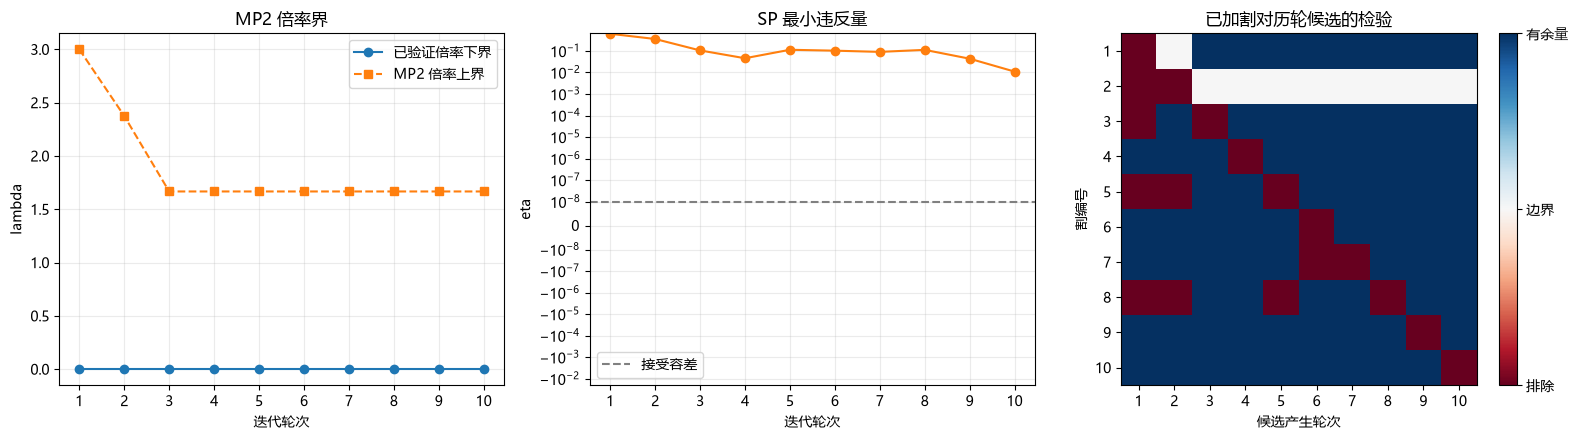

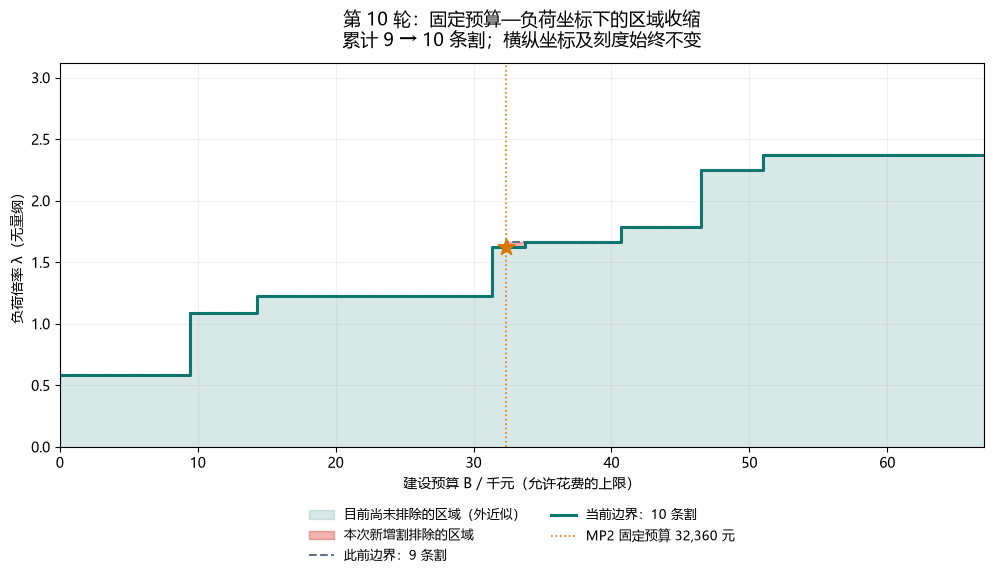

每个 (B, λ) 点表示：是否还存在至少一个费用不超过 B、且通过当前所有割的建设方案。
单次 MP1/MP2 收敛仅证明当前查询完成；恢复完整区域可运行 play_domain_cuts(full=True)。


In [6]:
STEPS = 10              # 1：每次运行只推进一轮；改成 20：逐轮自动播放，收敛后自动停止。
PAUSE = 1            # 自动播放时，两轮之间暂停的秒数。
SHOW_ALL_ROWS = False  # False：只显示非零 pi 对应的行；True：显示全部电气约束。

for step in range(STEPS):
    if finished:
        print(message + " 修改预算并重跑第五块，可开始新实验。")
        break
    result = step_mp2()
    clear_output(wait=True)  # 刷新画面；历史数据始终保存在 history、details、cuts 中。
    if result is None:
        print(message)
        display(pd.DataFrame(history))
        break

    k, previous = len(history), details.get(len(history) - 1)
    print(f"第 {k} 轮：MP2 → SP → {'接受方案' if finished else '添加新割'}")
    print(f"预算={TARGET_COST:,.0f} 元；候选倍率={result['lambda']:.9g}；候选费用={history[-1]['候选费用/元']:,.0f} 元；eta={result['eta']:.12g}")

    # A. 展示建设变量变化：保留本轮选中的项，以及较上一轮变化的项。
    x_before = previous["x"] if previous else np.full(model.nx, np.nan)
    x_table = pd.DataFrame({"建设变量": x_names, "上一轮": x_before, "本轮": result["x"]})
    mask = result["x"] != 0
    if previous: mask |= result["x"] != x_before
    print("\n建设选择：")
    display(x_table.loc[mask].reset_index(drop=True))

    # B. 展示 SP 求出的运行变量；eta>容差时，这些是放松后的试算值。
    w_before = previous["w"] if previous else np.full(len(w_names), np.nan)
    print("\nSP 运行变量（P：kW；v：平方电压；eta>容差时为放松后的试算值）：")
    display(pd.DataFrame({"变量": w_names, "本轮": result["w"], "较上一轮变化": result["w"] - w_before}))
    selected = result["rows"] if SHOW_ALL_ROWS else result["rows"].loc[np.abs(result["pi"]) > 1e-10]
    print("\n对偶乘子及对应约束：")
    display(selected[["b", "Ww", "原残差 Ww-b", "允许放松 rη", "放松后余量", "pi"]])
    print(f"对偶检查：max|W.T@pi|={result['stationarity']:.3e}；r@pi={result['normalization']:.12g}")

    # C. 显示刚加入的割，以及当前候选对所有已加割的满足情况。
    if result["cut"] is not None:
        print(f"\n新割 {len(cuts)}（显示值经舍入）：\n{cut_text(result['cut'])}")
        print(f"当前候选代入割的左端={result['margin']:.12g}；应等于 -eta={-result['eta']:.12g}")
        print("新割已经加入；下次运行本块，MP2 将在这些割的约束下重新选方案和倍率。")
    if cuts:
        display(pd.DataFrame({"割编号": range(1, len(cuts) + 1),
                              "当前候选代入左端": [c.constant + c.x_coeff @ result["x"] + c.lambda_coeff * result["lambda"] for c in cuts],
                              "本轮新增": [result["cut"] is c for c in cuts]}))

    # D. 历史表和图始终累计全部已完成的迭代，不会因刷新画面而丢失。
    trace = pd.DataFrame(history)
    print("\n累计迭代记录（本版本首次通过 SP 前，倍率下界保持为 0）：")
    display(trace)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
    ax[0].plot(trace["轮次"], trace["倍率下界"], "o-", label="已验证倍率下界")
    ax[0].plot(trace["轮次"], trace["倍率上界"], "s--", label="MP2 倍率上界")
    ax[0].set(title="MP2 倍率界", xlabel="迭代轮次", ylabel="lambda")
    ax[0].legend()
    ax[1].plot(trace["轮次"], trace["SP违反量"], "o-", color="tab:orange")
    ax[1].axhline(FEAS_TOL, color="gray", linestyle="--", label="接受容差")
    ax[1].set_yscale("symlog", linthresh=FEAS_TOL)  # 保留 eta=0，同时看清较小的违反量。
    ax[1].set(title="SP 最小违反量", xlabel="迭代轮次", ylabel="eta"); ax[1].legend()
    for axis in ax[:2]: axis.set_xticks(trace["轮次"]); axis.grid(alpha=0.25)

    # 每条已加割回测每个历史候选：红色表示排除，白色表示在边界，蓝色表示有余量。
    if cuts:
        margins = np.array([[c.constant + c.x_coeff @ rec["x"] + c.lambda_coeff * rec["lambda"]
                             for rec in details.values()] for c in cuts])
        signs = np.where(margins < -FEAS_TOL, -1, np.where(margins > FEAS_TOL, 1, 0))
        im = ax[2].imshow(signs, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
        ax[2].set_xticks(np.arange(k), np.arange(1, k + 1))
        ax[2].set_yticks(np.arange(len(cuts)), np.arange(1, len(cuts) + 1))
        bar = fig.colorbar(im, ax=ax[2], ticks=[-1, 0, 1])
        bar.ax.set_yticklabels(["排除", "边界", "有余量"])
    else:
        ax[2].text(0.5, 0.5, "尚未添加割", ha="center", va="center", transform=ax[2].transAxes)
    ax[2].set(title="已加割对历轮候选的检验", xlabel="候选产生轮次", ylabel="割编号")
    plt.tight_layout(); plt.show(); plt.close(fig)
    plot_domain_cuts(k) 
    if finished:
        print(message)
        break
    if step + 1 < STEPS: sleep(PAUSE)

# 回看某轮完整数据，例如：details[2]["rows"]、details[2]["pi"]、details[2]["x"]。
# 查看全部割的式子，例如：[cut_text(c) for c in cuts]。

### 固定坐标，看区域逐步被切掉

当前默认横轴是预算 $B$，纵轴是负荷倍率 $\lambda$，所有轮次的坐标含义和刻度都固定。
在第 $m$ 条割加入后，显示的区域是

$$\mathcal D_m=\{(B,\lambda):\exists x\in X_{\rm tree},\quad c^\mathsf{T}x\le B,
\quad 0\le\lambda\le\lambda_{\rm search},\quad g_i(x,\lambda)\ge0\ (i=1,\ldots,m)\}.$$

也就是：给定预算和负荷水平，是否还存在一个通过目前所有割的建设方案。
随着加入新割，$\mathcal D_{m+1}\subseteq\mathcal D_m$；绿色是尚未排除的部分，红色是本次新排除的部分。
预算 $B$ 是允许花费的上限，不是某个唯一方案的实际费用。一个 $(B,\lambda)$ 点可以对应多个建设方案。
本模型中零负荷下所有结构合法方案均可行，所以固定预算下的允许倍率从 0 连续到上界。

**与二维新能源可调度域的区别：** 这里有 15 个二元建设变量。投影后的预算域一般是非凸阶梯，
不能把某条高维割直接改写成 $aB+b\lambda+c\ge0$，更不能把阶梯的凸包当作原整数可行域。
要让每条割直接表现为一条直线或一个平面，需要模型以固定的 2—3 个连续参数为展示变量，
或明确固定其他变量后画截面。固定其余变量得到的是截面，并不代表完整域。

默认第 4、6 块会逐轮调用 `plot_domain_cuts(k)`。
`plot_domain_cuts(0)` 看初始域；`play_domain_cuts()` 回放当前已有割。
`play_domain_cuts(full=True)` 用独立模型跨预算求解 MP2、MP1，并逐条回放完整规划域的恢复过程，
不会修改当前实验的 `master`、`cuts`、`history` 或 `details`。
绘图保留全部整数方案费用跳点，枚举只用于显示与独立校验，求解选点和生成割仍由原主/子问题完成。

**局部查询与完整域：** 当前 MP1 收敛，只说明固定倍率的最低费用已确定；当前 MP2 收敛，只说明固定预算的最大倍率已确定。
其他预算处可能仍有多余区域。只有完整前沿搜索并校验后，才把最终外近似称为本模型的可行域。
某条割也可能只排除一种方案，而其他方案仍支撑相同的预算—负荷点，此时图上外轮廓暂时不动。

以下保留原来单条割三维图的解释；它可通过 `plot_mp1_cut(k)` 单独调用。

### 为什么是割平面？$g_k(x,\lambda)$ 是什么？

本例中 $x\in\{0,1\}^{15}$ 表示 5 条走廊、每条 3 种线型的建设选择，
$\lambda$ 是负荷倍率。MP1 固定 $\lambda$ 并最小化建设费用 $K(x)=c^\mathsf{T}x$；
MP2 限制建设预算并最大化 $\lambda$。

SP 检查固定方案能否满足电气约束：

$$\min_{w,\eta\ge0}\eta,\qquad Ww\le h+Tx+d\lambda+r\eta.$$

第 $k$ 轮读取的对偶向量 $\pi_k$ 满足
$\pi_k\ge0$、$W^\mathsf{T}\pi_k=0$、$r^\mathsf{T}\pi_k\le1$。
对任何真正电气可行的方案，取 $\eta=0$，将原约束左乘 $\pi_k^\mathsf{T}$ 就得到

$$0=\pi_k^\mathsf{T}Ww\le\pi_k^\mathsf{T}(h+Tx+d\lambda).$$

因此新增的**可行性割**是

$$\underbrace{\pi_k^\mathsf{T}h+(\pi_k^\mathsf{T}T)x+(\pi_k^\mathsf{T}d)\lambda}_{g_k(x,\lambda)}\ge0.$$

- $g_k$ 只是这一条割左端的函数名。每条割的 $\pi_k$ 不同，因而 $g_k$ 也不同。
- $g_k<0$ 表示违反这条割；$g_k=0$ 是边界；$g_k>0$ 表示满足这条割。实际代码按数值容差判断。
- 它不是建设费用，不是到平面的欧氏距离，也不是另一个需要优化的目标。
- 在**产生本条割的候选点** $(x^k,\lambda^k)$，强对偶给出
  $g_k(x^k,\lambda^k)=-\eta_k^*<0$，所以这个候选一定被新割排除。
  换到其他点后，固定这条割的 $g_k$ 一般不等于该点重新求 SP 得到的 $-\eta^*$。
- 满足一条割或目前全部割，只表示暂时未被排除，仍需 SP 验证。

**关于维数：** 割边界原本是 16 维 $(x,\lambda)$ 空间中的超平面；固定倍率的 MP1
则是在该空间的固定 $\lambda$ 截面上选整数方案。不能把 15 维 $x$ 无说明地画成一个标量。
第 3 块定义 $u=(\pi_k^\mathsf{T}T)x$，在 $(u,\lambda,K)$ 坐标中显示

$$\pi_k^\mathsf{T}h+u+(\pi_k^\mathsf{T}d)\lambda=0.$$

这是对**当前这一条割**保留正负判断的三维展示。平面沿费用轴延展，因为这条可行性割里
没有 $K$ 的系数。图中的连续平面用于展示边界，不表示所有平面位置都有合法的整数建设方案。
不同建设方案可能重叠在同一个投影点上；换一条割时，$u$ 的含义也会随其系数变化。
纯倍率割不含 $x$，图中改用一个实际 $x$ 分量展示，并画出与建设变量无关的常倍率平面。

**默认参数下的具体例子：** MP1 第一轮割为

$$\frac7{60}(x_{01,L}+x_{02,L})+\frac{13}{60}(x_{01,M}+x_{02,M})
+\frac13(x_{01,H}+x_{02,H})-0.2\lambda\ge0.$$

令前三项之和为 $u$，割就是 $u-0.2\lambda\ge0$。当 $\lambda=1.3$ 时，要求 $u\ge0.26$。
第一轮零新增费用的旧方案有 $u=7/60$，故 $g_1=7/60-0.26=-0.143333\ldots$，在被切掉的一侧。
此处说明的是建设贡献不足；并不是直接添加“费用必须大于某个值”的约束。

**MP2 的红段：** 同一个 $x$ 通常允许一段 $\lambda$。新割可能只削低倍率上限，而不删除整个建设方案。
左图显示预算和旧割允许的倍率区间如何被新割截短；右图只检查当轮候选倍率这一层。
例如默认 MP2 第一轮得到 $2.375-\lambda\ge0$，即把倍率上限从 3 降到 2.375。

运行顺序：MP1 用第 1、2、3、4 块；MP2 可接着运行第 5、6 块。
`STEPS=1` 每次推进一轮，现有 `STEPS=10` 每次最多推进十轮；图不会额外推进求解。
`plot_mp1_cut(1)` 回看当前实验第一轮，`plot_mp1_cut(1, elev=30, azim=-35)` 更换观察角度。
函数同时支持 MP1、MP2；保留原名称以兼容两处调用。
无新增割的收敛轮会明确标注并回看最近一条割。重跑初始化块后，历史归属于新实验。


### 两区域负荷：固定坐标的完整三维切割过程

- **x 轴：区域 A 负荷倍率 $\lambda_A$**（节点 1，基准 25 kW）；**y 轴：区域 B 负荷倍率 $\lambda_B$**（节点 2、3，基准共 35 kW）；**竖直 z 轴：建设成本上限 $B$（千元）**。
- 例如 $(\lambda_A,\lambda_B,B)=(1.2,1.8,32.36)$ 表示：预算 32360 元以内，节点 1 为 30 kW，节点 2、3 合计 63 kW；考察是否存在满足电气约束的建设方案。
- 电气右端为 $h+Tx+D_A\lambda_A+D_B\lambda_B$，每条真实对偶割为
  $\pi^T h+\pi^TTx+(\pi^TD_A)\lambda_A+(\pi^TD_B)\lambda_B\ge0$。
  $D_A+D_B=d$，所以 $\lambda_A=\lambda_B$ 的斜截面严格还原原单倍率模型。
- 三维图绘制
  $\mathcal D_t=\{(\lambda_A,\lambda_B,B):\exists x\in X_{tree},c^Tx\le B,\text{前 }t\text{ 条割成立}\}$。
  中间为外近似，最终为当前线性电气模型和搜索范围内的完整可规划域。
- **一条原始割固定建设方案后才是一条负荷平面。** 投影到 $(\lambda_A,\lambda_B,B)$ 后需要合并各建设方案，呈现台阶、折面甚至凹陷，不能用一个凸包代替，也不能把某方案的割平面对所有方案直接切除。

为了覆盖两个连续倍率的整个域，这个独立实验枚举 216 种合法建设方案，检查当前候选多边形的顶点，并用 SP 的对偶乘子生成全局割。它是“有限方案枚举 + SP 顶点分离”的完整域实验，**不是上面某次 MP1/MP2 查询的逐轮轨迹**。所有最终顶点可行时，按凸性可证明对应整个多边形可行；另用树上潮流、电压、容量公式逐方案交叉核验。

结果共 182 条割，其中 71 条改变总体投影体积；其余割收紧某些方案，但其他方案仍覆盖相同坐标。图形并集按全部费用断点精确构造，没有对预算或两个倍率做网格采样。

下面显示可旋转、可拖动步数、可播放的完整过程，并给出最终静态图。`REBUILD_3D=True` 可重新求解；默认读取已验证结果。


竖轴 $B$ 是允许的建设成本上限；最终台阶下边界就是该负荷组合所需的最低建设成本。中间步骤的下边界是成本的下界，新的割可能把它向上抬高。边界上方为保留域，低于它的预算被排除。为看清这些台阶，图中打开人为搜索盒子的顶盖和零负荷侧壁；完整保留域和排除体积仍按同一精确几何计算。


三维坐标：x=区域 A 负荷倍率 / y=区域 B 负荷倍率 / z=建设成本上限（千元）
真实割： 182 条；完整域验证： True


C:\Users\10856\miniconda3\envs\methods\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


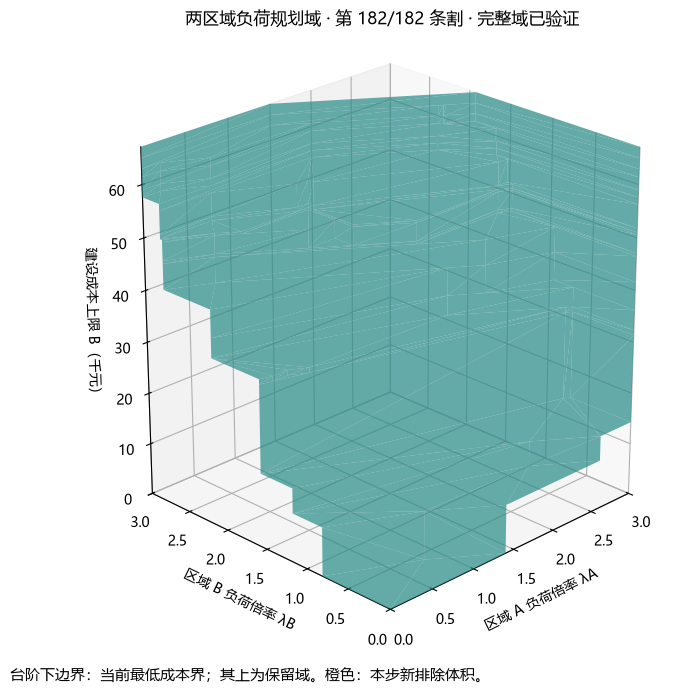

In [7]:
# 三维完整域实验：与上面的 MP1、MP2 迭代状态独立。
from pathlib import Path
from html import escape
from IPython.display import HTML, display
import load_region_3d as region3d

REBUILD_3D = False
if REBUILD_3D or not (region3d.OUTPUT / 'cuts_and_verification.json').exists():
    region3d_process = region3d.run_complete_process()
    region3d.export_display_data(region3d_process[0], region3d_process[2])
else:
    region3d_process = region3d.load_process()

print('三维坐标：x=区域 A 负荷倍率 / y=区域 B 负荷倍率 / z=建设成本上限（千元）')
print('真实割：', len(region3d_process[0]['cuts']), '条；完整域验证：', region3d_process[0]['verification']['complete'])
interactive_page = region3d.OUTPUT / 'three_dimensional_cut_process.html'
if interactive_page.exists() and not REBUILD_3D:
    # 独立内嵌页面支持 Jupyter 中的旋转和播放；静态图可在禁用脚本时查看。
    page = escape(interactive_page.read_text(encoding='utf-8'), quote=True)
    display(HTML(f'<iframe title="完整三维切割过程" srcdoc="{page}" width="100%" height="760" style="border:0"></iframe>'))

fig3d = region3d.plot_region_step(process=region3d_process)
display(fig3d)
plt.close(fig3d)

# 任意一步：region3d.plot_region_step(20, process=region3d_process)
# 从第 0 步开始逐条回放全部割：region3d.play_region_cuts(pause=0.7)
